<a href="https://colab.research.google.com/github/ancestor9/Introduction-to-BigData-Analysis/blob/main/7%EC%A3%BC%EC%B0%A8/pandas_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Getting started tutorials**

| No. | Title | Description |
|-----|-------|-------------|
||||
|----->|**pandas_01.ipynb**|--|
| 1 | What kind of data does pandas handle? (판다스는 어떤 종류의 데이터를 다루는가?) | Tabular data, time series, labeled data with axes, structured mixed-type data |
| 2 | How do I read and write tabular data? (표 형식 데이터를 어떻게 읽고 쓰는가?) | Use `pd.read_csv()`, `pd.read_excel()` to read; `df.to_csv()`, `df.to_excel()` to write |
| 3 | How do I select a subset of a DataFrame? (DataFrame에서 부분 선택은 어떻게 하는가?) | Use column selection, `df.loc[]`, `df.iloc[]`, and condition filtering |
||||
||||
|----->|**pandas_02.ipynb**|--|
| 4 | How do I create plots in pandas? (판다스에서 시각화를 어떻게 하는가?) | Use `df.plot()`, `df.hist()`, etc., built on `matplotlib` |
| 5 | How to create new columns derived from existing columns (기존 열로부터 새 열을 만드는 방법은?) | Perform operations like `df['new'] = df['a'] + df['b']` or use functions |
| 6 | How to calculate summary statistics (요약 통계를 계산하는 방법은?) | Use methods like `df.describe()`, `df.mean()`, `df.std()`, etc. |
||||
||||
|----->|**pandas_03.ipynb**|--|
| 7 | How to reshape the layout of tables (테이블 구조를 변경하는 방법은?) | Use `pivot()`, `melt()`, `stack()`, `unstack()`, or transpose with `df.T` |
| 8 | How to combine data from multiple tables (여러 테이블의 데이터를 결합하는 방법은?) | Use `pd.concat()`, `pd.merge()`, or `df.join()` by key/index |
| 9 | How to handle time series data with ease (시계열 데이터를 쉽게 다루는 방법은?) | Use `pd.to_datetime()`, `resample()`, `set_index()`, and time-based slicing |
| 10 | How to manipulate textual data (문자 데이터를 조작하는 방법은?) | Use `str` methods like `.lower()`, `.contains()`, `.replace()` with regex |


#<font color='orange'> **1. What kind of data does pandas handle?**
### pandas data table representation
- **DataFrame는 column과 row로 구성**
<img src ='https://pandas.pydata.org/docs/_images/01_table_dataframe.svg'>


## Python의 Data Structures 는 모두 데이터프레임으로 변환가능하다


In [15]:
data  = list(range(5)) # set, tuple
data

[0, 1, 2, 3, 4]

In [21]:
import pandas as pd
df = pd.DataFrame(data)  # pd.Series()
df

,0
0,0
1,1
2,2
3,3
4,4


In [18]:
# prompt: 사전형자료 5개 만 만들어줘

mydicts = [{'a': 1, 'b': 2}, {'a': 3, 'b': 4}, {'a': 5, 'b': 6}, {'a': 7, 'b': 8}, {'a': 9, 'b': 10}]
mydicts

[{'a': 1, 'b': 2},
 {'a': 3, 'b': 4},
 {'a': 5, 'b': 6},
 {'a': 7, 'b': 8},
 {'a': 9, 'b': 10}]

In [19]:
df = pd.DataFrame(mydicts)
df

,a,b
0,1,2
1,3,4
2,5,6
3,7,8
4,9,10


In [22]:
data = {
        "Name": [
            "Braund, Mr. Owen Harris",
            "Allen, Mr. William Henry",
            "Bonnell, Miss. Elizabeth",
        ],
        "Age": [22, 35, 58],
        "Sex": ["male", "male", "female"],
    }

In [23]:
df = pd.DataFrame(data)
df

,Name,Age,Sex
0,"Braund, Mr. Owen Harris",22,male
1,"Allen, Mr. William Henry",35,male
2,"Bonnell, Miss. Elizabeth",58,female


In [38]:
# prompt: fake 를 사용하여 100개의 name, age, salary, address, email, telephone 을  데이터프레임으로 만들어줘
!pip install faker -q
from faker import Faker
fake = Faker()

data = {
    "Name": [fake.name() for _ in range(100)],
    "Age": [fake.random_int(min=18, max=90) for _ in range(100)],
    "Salary": [fake.random_int(min=20000, max=100000) for _ in range(100)],
    "Address": [fake.address() for _ in range(100)],
    "Email": [fake.email() for _ in range(100)],
    "Telephone": [fake.phone_number() for _ in range(100)],
}

df = pd.DataFrame(data)
df

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 51.4 MB/s eta 0:00:00


,Name,Age,Salary,Address,Email,Telephone
0,Kimberly Ortiz,82,84267,"20813 Christopher Prairie\nStephanieborough, A...",michael36@example.net,358-893-6711
1,Kayla Lee,61,21432,"PSC 9330, Box 2977\nAPO AE 25174",fisherallison@example.org,5024135356
2,Kelsey Friedman,74,51747,"346 Haynes Shore Suite 619\nNew Chrisberg, IN ...",wardmitchell@example.org,+1-557-325-4604x8979
3,Ryan Oliver,26,79036,"412 Zachary Vista\nLake Michelle, HI 72332",morrisnicole@example.com,708-529-9245x8795
4,Christopher Malone,65,85047,"6774 Robert Meadow Apt. 270\nThompsonside, NJ ...",jessica00@example.net,001-745-582-4944
...,...,...,...,...,...,...
95,Christopher Miller II,50,29302,"79800 Melissa Road\nHallfurt, NC 61624",smithlarry@example.net,748.912.9970x39677
96,Dustin Mora,29,87922,"702 Michael Camp\nPort Mitchell, CA 35916",rtrujillo@example.net,322.212.4234
97,Joseph Green,18,46734,"6134 Keith Summit Suite 754\nSouth Laurenside,...",nancy69@example.net,459-883-7016x442
98,Michael Higgins,52,60766,"95405 Gomez Estates\nNew Samanthabury, SC 97934",jennifer70@example.org,982.787.1599x980


In [39]:
type(df)

pandas.core.frame.DataFrame

In [40]:
df["Age"]  # Series

,Age
0,82
1,61
2,74
3,26
4,65
...,...
95,50
96,29
97,18
98,52


In [41]:
type(df['Age'])

pandas.core.series.Series

In [44]:
ages = pd.Series(df['Age'], name="Age") # 컬럼이 Age
ages

,Age
0,82
1,61
2,74
3,26
4,65
...,...
95,50
96,29
97,18
98,52


In [45]:
type(ages)

pandas.core.series.Series

In [46]:
df["Age"].max() # 최대값

90

In [47]:
ages.min() # 최소값

18

In [48]:
ages.mean() # 평균

np.float64(53.72)

In [49]:
ages.median() # 중앙값

54.5

In [50]:
df.describe()  # Numeric 데이터 형태만 출력

,Age,Salary
count,100.000000,100.000000
mean,53.720000,61980.820000
std,21.448119,23358.849875
min,18.000000,20865.000000
25%,35.000000,42592.750000
50%,54.500000,62087.500000
75%,74.000000,84323.250000
max,90.000000,99088.000000


<Axes: >

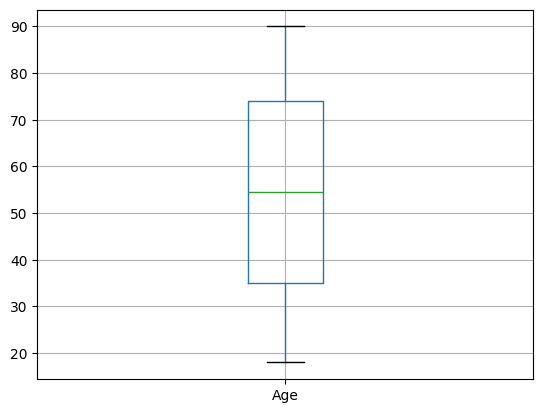

In [56]:
df.boxplot(column='Age')

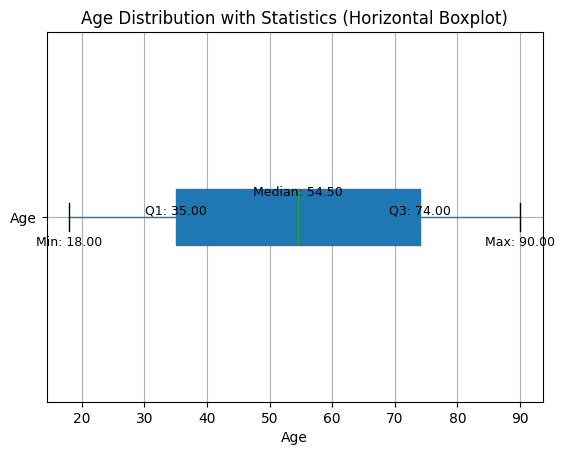

In [60]:
# prompt: df.boxplot(column='Age') 시각화에 25%, 75%, median. max. min을 표기해줘. 수평 막대상자로

import matplotlib.pyplot as plt

# Calculate statistics
age_stats = df['Age'].describe()
q1 = age_stats['25%']
median = age_stats['50%']
q3 = age_stats['75%']
minimum = age_stats['min']
maximum = age_stats['max']

# Boxplot을 수평으로 그리기 위해 vert=False 옵션 사용
boxplot = df.boxplot(column='Age', vert=False, patch_artist=True)

# Matplotlib의 Axes 객체 가져오기
ax = boxplot.get_figure().get_axes()[0]

# Add text annotations for statistics
# The y-coordinate for horizontal boxplots is typically 1 (or close to it) for the first box
y_text_position = 1

ax.text(q1, y_text_position, f'Q1: {q1:.2f}', va='bottom', ha='center', fontsize=9, color='black')
ax.text(median, y_text_position + 0.05, f'Median: {median:.2f}', va='bottom', ha='center', fontsize=9, color='black')
ax.text(q3, y_text_position, f'Q3: {q3:.2f}', va='bottom', ha='center', fontsize=9, color='black')
ax.text(minimum, y_text_position - 0.05, f'Min: {minimum:.2f}', va='top', ha='center', fontsize=9, color='black')
ax.text(maximum, y_text_position - 0.05, f'Max: {maximum:.2f}', va='top', ha='center', fontsize=9, color='black')


plt.title('Age Distribution with Statistics (Horizontal Boxplot)')
plt.xlabel('Age')
plt.show()

<img src='https://api.www.labxchange.org/api/v1/xblocks/lb:LabXchange:d8863c77:html:1/storage/211626365402575-b88c4d0fdacd5abb4c3dc2de3bc004bb.png'>

### **The anatomy of a boxplot**
- Boxplots are a good way to visualize data sets since they display a lot of important information in a simple, standard format.
- Boxplots describe data sets using 5 particular numbers: the minimum, first quartile, median, third quartile, and maximum.
- The box in the diagram begins with the first quartile and ends with the third quartile, with the median indicated as a line that divides the box.
- Lines extend from the first quartile down to the minimum and from the third quartile up to the maximum. 25% of the data values in the data set fall between the minimum and the first quartile; 25% of the data values fall between the first quartile and the median; 25% of the data values fall between the median and the third quartile; 25% of the data values fall between the third quartile and the maximum.

# **<font color='orange'>2. How do I read and write tabular data?**

<img src='https://pandas.pydata.org/docs/_images/02_io_readwrite.svg'>

In [51]:
df

,Name,Age,Salary,Address,Email,Telephone
0,Kimberly Ortiz,82,84267,"20813 Christopher Prairie\nStephanieborough, A...",michael36@example.net,358-893-6711
1,Kayla Lee,61,21432,"PSC 9330, Box 2977\nAPO AE 25174",fisherallison@example.org,5024135356
2,Kelsey Friedman,74,51747,"346 Haynes Shore Suite 619\nNew Chrisberg, IN ...",wardmitchell@example.org,+1-557-325-4604x8979
3,Ryan Oliver,26,79036,"412 Zachary Vista\nLake Michelle, HI 72332",morrisnicole@example.com,708-529-9245x8795
4,Christopher Malone,65,85047,"6774 Robert Meadow Apt. 270\nThompsonside, NJ ...",jessica00@example.net,001-745-582-4944
...,...,...,...,...,...,...
95,Christopher Miller II,50,29302,"79800 Melissa Road\nHallfurt, NC 61624",smithlarry@example.net,748.912.9970x39677
96,Dustin Mora,29,87922,"702 Michael Camp\nPort Mitchell, CA 35916",rtrujillo@example.net,322.212.4234
97,Joseph Green,18,46734,"6134 Keith Summit Suite 754\nSouth Laurenside,...",nancy69@example.net,459-883-7016x442
98,Michael Higgins,52,60766,"95405 Gomez Estates\nNew Samanthabury, SC 97934",jennifer70@example.org,982.787.1599x980


## **엑셀파일 만들기, 외부 엑셀파일 읽기**

In [63]:
# prompt: df DataFrame 사용: 엑셀로 저장해줘

# Save the DataFrame to an Excel file named 'output.xlsx'
df.to_excel('output.xlsx')

In [64]:
# prompt: /content/output.xlsx 을 읽어줘

# Read the Excel file 'output.xlsx' into a DataFrame
df = pd.read_excel('/content/output.xlsx')

In [65]:
df.head()

,Unnamed: 0,Name,Age,Salary,Address,Email,Telephone
0,0,Kimberly Ortiz,82,84267,"20813 Christopher Prairie\nStephanieborough, A...",michael36@example.net,358-893-6711
1,1,Kayla Lee,61,21432,"PSC 9330, Box 2977\nAPO AE 25174",fisherallison@example.org,5024135356
2,2,Kelsey Friedman,74,51747,"346 Haynes Shore Suite 619\nNew Chrisberg, IN ...",wardmitchell@example.org,+1-557-325-4604x8979
3,3,Ryan Oliver,26,79036,"412 Zachary Vista\nLake Michelle, HI 72332",morrisnicole@example.com,708-529-9245x8795
4,4,Christopher Malone,65,85047,"6774 Robert Meadow Apt. 270\nThompsonside, NJ ...",jessica00@example.net,001-745-582-4944


In [66]:
# prompt: df DataFrame 사용: Unnamed: 0 은 제거해줘

# Drop the 'Unnamed: 0' column from the dataframe
df = df.drop('Unnamed: 0', axis=1)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       100 non-null    object
 1   Age        100 non-null    int64 
 2   Salary     100 non-null    int64 
 3   Address    100 non-null    object
 4   Email      100 non-null    object
 5   Telephone  100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


In [68]:
df.describe()

,Age,Salary
count,100.000000,100.000000
mean,53.720000,61980.820000
std,21.448119,23358.849875
min,18.000000,20865.000000
25%,35.000000,42592.750000
50%,54.500000,62087.500000
75%,74.000000,84323.250000
max,90.000000,99088.000000


#<font color='orange'> **3. How do I select a subset of a DataFrame?**
##<font color='orange'> **3.1. How do I select specific columns from a DataFrame?**

<img src='https://pandas.pydata.org/docs/_images/03_subset_columns.svg'>

In [69]:
# prompt: seabeorn 에서 titanic을 읽어줘

import seaborn as sns

titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [70]:
titanic.shape

(891, 15)

In [71]:
ages = titanic["age"]
ages

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,NaN
889,26.0


In [72]:
ages.shape

(891,)

In [73]:
age_sex = titanic[["age", "sex"]]
age_sex

,age,sex
0,22.0,male
1,38.0,female
2,26.0,female
3,35.0,female
4,35.0,male
...,...,...
886,27.0,male
887,19.0,female
888,NaN,female
889,26.0,male


In [74]:
type(age_sex)

pandas.core.frame.DataFrame

In [75]:
age_sex.shape

(891, 2)

## <font color='orange'>**3.2. How do I filter specific rows from a DataFrame?**

In [76]:
above_35 = titanic[titanic["age"] > 35]
above_35

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
13,0,3,male,39.0,1,5,31.2750,S,Third,man,True,NaN,Southampton,no,False
15,1,2,female,55.0,0,0,16.0000,S,Second,woman,False,NaN,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,1,2,female,42.0,0,0,13.0000,S,Second,woman,False,NaN,Southampton,yes,True
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
873,0,3,male,47.0,0,0,9.0000,S,Third,man,True,NaN,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False


In [77]:
titanic["age"] > 35

,age
0,False
1,True
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [78]:
above_35.shape


(217, 15)

In [79]:
titanic.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [80]:
titanic["pclass"].unique()

array([3, 1, 2])

In [81]:
titanic["pclass"].isin([2, 3])

,pclass
0,True
1,False
2,True
3,False
4,True
...,...
886,True
887,False
888,True
889,False


In [82]:
class_23 = titanic[titanic["pclass"].isin([2, 3])]
class_23

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


In [83]:
titanic[(titanic["pclass"] == 2) | (titanic["pclass"] == 3)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False


In [84]:
titanic[(titanic["pclass"] == 3) & (titanic["age"] > 45)]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
94,0,3,male,59.0,0,0,7.2500,S,Third,man,True,NaN,Southampton,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
132,0,3,female,47.0,1,0,14.5000,S,Third,woman,False,NaN,Southampton,no,False
152,0,3,male,55.5,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
203,0,3,male,45.5,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True
222,0,3,male,51.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
280,0,3,male,65.0,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True
326,0,3,male,61.0,0,0,6.2375,S,Third,man,True,NaN,Southampton,no,True
406,0,3,male,51.0,0,0,7.7500,S,Third,man,True,NaN,Southampton,no,True
482,0,3,male,50.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [85]:
len(titanic[(titanic["pclass"] == 3) & (titanic["age"] > 45)])

18

In [86]:
len(titanic[(titanic["pclass"] == 3) & (titanic["age"] > 45) & (titanic["alive"] == "yes")])

1

In [87]:
1/18*100

5.555555555555555

In [88]:
for i in range(1, 4):
    a = len(titanic[(titanic["pclass"] == i) & (titanic["age"] > 45)])
    b = len(titanic[(titanic["pclass"] == i) & (titanic["age"] > 45) & (titanic["alive"] == "yes")])
    print(f'{i} class의 생존율은 {b/a*100:.2f}%')

1 class의 생존율은 48.39%
2 class의 생존율은 30.43%
3 class의 생존율은 5.56%


In [89]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [90]:
age_no_na = titanic[titanic["age"].notna()]
age_no_na

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [91]:
titanic.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [92]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


##<font color='orange'> **3.3. How do I select specific rows and columns from a DataFrame?**

<img src ='https://pandas.pydata.org/docs/_images/03_subset_columns_rows.svg'>

In [93]:
titanic.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [95]:
adult_fare = titanic.loc[titanic["age"] > 45, "fare"]
adult_fare

,fare
6,51.8625
11,26.5500
15,16.0000
33,10.5000
52,76.7292
...,...
857,26.5500
862,25.9292
871,52.5542
873,9.0000


In [96]:
titanic.iloc[9:25, 2:5]

,sex,age,sibsp
9,female,14.0,1
10,female,4.0,1
11,female,58.0,0
12,male,20.0,0
13,male,39.0,1
14,female,14.0,0
15,female,55.0,0
16,male,2.0,4
17,male,NaN,0
18,female,31.0,1


In [97]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [98]:
titanic.iloc[0:3, 3]

,age
0,22.0
1,38.0
2,26.0


In [99]:
titanic.iloc[0:3, 3] = 999
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,999.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,999.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,999.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
